In this notebook we are going to:

- solve a linear parameter identification problem with ordinary least squares (OLS) and prediction error method (PEM),
- evaluate the found parameter sets in the cost-parameter plane.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import optimize

# RNG (seed to reproduce results)
rng = np.random.default_rng(14588)

Consider a simple first-order, discrete-time dynamic linear system: $x[k+1] = ax[k] + bu[k]$.\
First, we will generate simulated system response data including measurement noise.

In [2]:
# system and input generation
Delta_t = 1.0  # time step in s
Vs = 1.0
tau = 15.0

a = (1 - Delta_t / tau)
b = (Vs * Delta_t / tau)

# input: piecewise steps
N = 1000
u = np.zeros(N)
u[0:250] = 1.0
u[250:500] = -1.0
u[500:750] = 1.0
u[750:1000] = -1.0

# simulate noiseless state x
x = np.zeros(N)
for k in range(1, N):
    x[k] = a * x[k-1] + b * u[k-1]

# add measurement noise
sigma = 0.1
y = x + sigma * rng.normal(size=N)

Next, we repeat ordinary least squares (OLS) identification to show its sensitivity to measurement noise.

In [3]:
# OLS setup (predict y[k] from y[k-1] and u[k-1])
Y_OLS = y[1:]
Z_OLS = np.column_stack((y[:-1], u[:-1]))
# use least-squares for numerical stability
w_OLS, *_ = np.linalg.lstsq(Z_OLS, Y_OLS, rcond=None)

def predict(w, u, N):
    x_hat = np.zeros(N)
    for k in range(1, N):
        x_hat[k] = w[0] * x_hat[k-1] + w[1] * u[k-1]
    return x_hat

x_hat_OLS = predict(w_OLS, u, N)

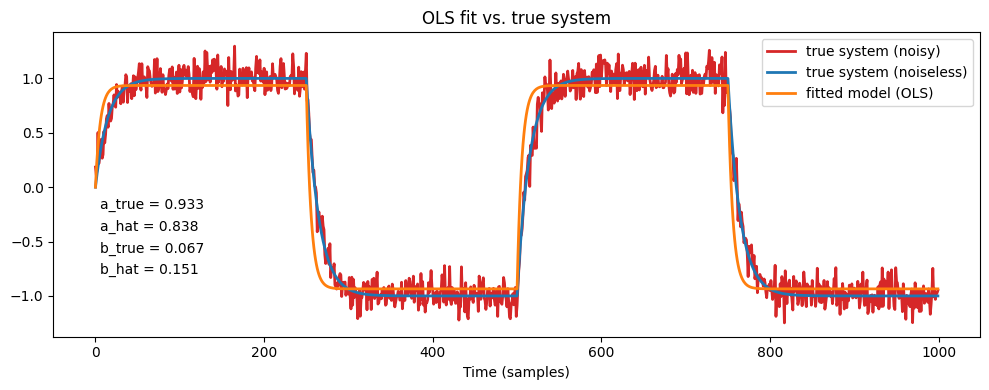

In [6]:
# plot OLS result vs. ground truth
plt.figure(figsize=(10,4))
plt.plot(y, label='true system (noisy)', linewidth=2, color='C3')
plt.plot(x, label='true system (noiseless)', linewidth=2, color='C0')
plt.plot(x_hat_OLS, label='fitted model (OLS)', linewidth=2, color='C1')
plt.xlabel('Time (samples)')
plt.legend()
plt.title('OLS fit vs. true system')
# annotate estimated and true parameters
plt.text(5, -0.4, f"a_hat = {w_OLS[0]:.3f}")
plt.text(5, -0.8, f"b_hat = {w_OLS[1]:.3f}")
plt.text(5, -0.2, f"a_true = {a:.3f}")
plt.text(5, -0.6, f"b_true = {b:.3f}")
plt.tight_layout()
plt.show()

To improve estimates we use a direct parameter optimization (prediction error method, PEM) that minimizes the sum of squared prediction errors over the whole trajectory.

In [ ]:
def costs(w, u, y):
    N = len(u)
    x_sim = np.zeros(N)
    for k in range(1, N):
        x_sim[k] = w[0] * x_sim[k-1] + w[1] * u[k-1] #linear model
    return np.sum((y - x_sim)**2)

We use SciPy's optimizer to minimize the cost function and obtain the PEM solution.

C:\Users\27abd\AppData\Local\Temp\ipykernel_9848\1171411987.py:5: RuntimeWarning: overflow encountered in scalar multiply
  x_sim[k] = w[0] * x_sim[k-1] + w[1] * u[k-1]
C:\Users\27abd\AppData\Local\Temp\ipykernel_9848\1171411987.py:6: RuntimeWarning: overflow encountered in square
  return np.sum((y - x_sim)**2)
C:\Users\27abd\AppData\Roaming\Python\Python312\site-packages\scipy\optimize\_numdiff.py:686: RuntimeWarning: invalid value encountered in subtract
  df = [f_eval - f0 for f_eval in f_evals]
C:\Users\27abd\AppData\Local\Temp\ipykernel_9848\1171411987.py:5: RuntimeWarning: overflow encountered in scalar multiply
  x_sim[k] = w[0] * x_sim[k-1] + w[1] * u[k-1]
C:\Users\27abd\AppData\Local\Temp\ipykernel_9848\1171411987.py:6: RuntimeWarning: overflow encountered in square
  return np.sum((y - x_sim)**2)


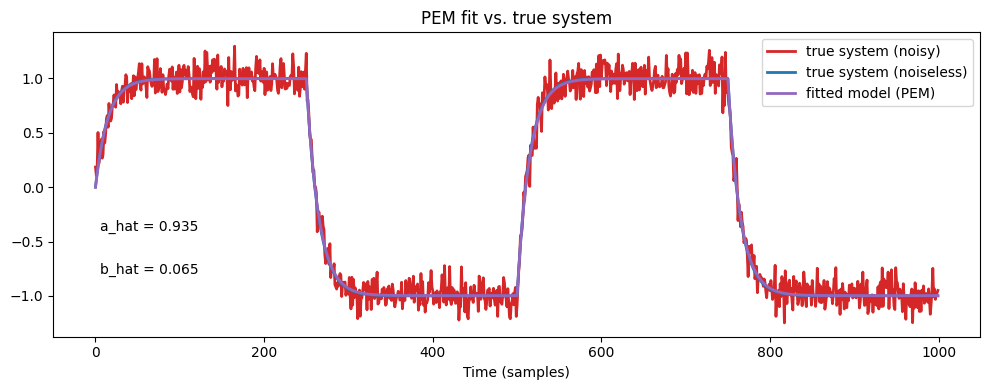

In [9]:
res = optimize.minimize(lambda w: costs(w, u, y), x0=np.array([0.0, 0.0]), method='BFGS')
w_PEM = res.x
x_hat_PEM = predict(w_PEM, u, N)

plt.figure(figsize=(10,4))
plt.plot(y, label='true system (noisy)', linewidth=2, color='C3')
plt.plot(x, label='true system (noiseless)', linewidth=2, color='C0')
plt.plot(x_hat_PEM, label='fitted model (PEM)', linewidth=2, color='C4')
plt.xlabel('Time (samples)')
plt.legend()
plt.title('PEM fit vs. true system')
plt.text(5, -0.4, f"a_hat = {w_PEM[0]:.3f}")
plt.text(5, -0.8, f"b_hat = {w_PEM[1]:.3f}")
plt.tight_layout()
plt.show()

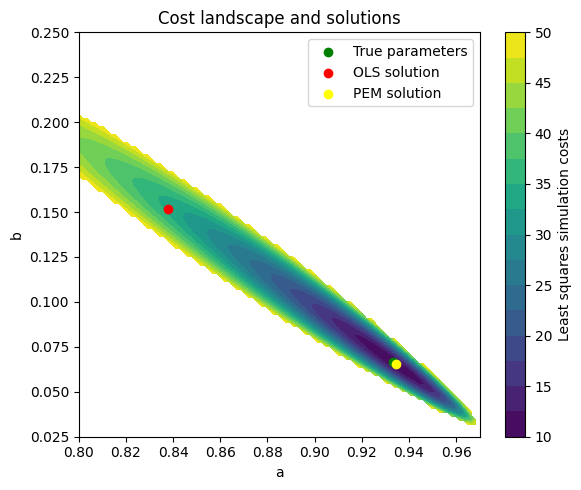

In [11]:
# compare OLS and PEM in cost landscape
a_vec = np.linspace(0.8, 0.97, 100)
b_vec = np.linspace(0.025, 0.25, 100)
A, B = np.meshgrid(a_vec, b_vec)
costvalue = np.empty_like(A)
for i in range(A.shape[0]):
    for j in range(A.shape[1]):
        costvalue[i, j] = costs([A[i, j], B[i, j]], u, y)

costvalue[costvalue > 50] = np.nan

plt.figure(figsize=(6,5))
cp = plt.contourf(a_vec, b_vec, costvalue, levels=15, cmap='viridis')
plt.colorbar(cp, label='Least squares simulation costs')
plt.scatter([a], [b], color='green', label='True parameters')
plt.scatter([w_OLS[0]], [w_OLS[1]], color='red', label='OLS solution')
plt.scatter([w_PEM[0]], [w_PEM[1]], color='yellow', label='PEM solution')
plt.xlabel('a')
plt.ylabel('b')
plt.legend()
plt.title('Cost landscape and solutions')
plt.tight_layout()
plt.show()